# Cross-Sectional Momentum — Nifty Large-Cap Universe
### Backtested systematic equity strategy with out-of-sample validation and factor analysis

**Hypothesis:** Stocks with the highest returns over the past 12 months (excluding the most
recent month) tend to outperform the following month. Buying the top decile monthly beats
the Nifty on a risk-adjusted basis after costs.

**Key design choices:**
- Walk-forward, no look-ahead bias
- 0.20% one-way transaction cost scaled by actual turnover
- In-sample (2010–2017) and out-of-sample (2018–2025) split for validation
- Robustness sweep across four lookback windows
- Sector exposure and market beta analysis

> **Survivorship bias present** — universe uses today's constituent list.
> Results overstate live performance. Estimated inflation: 2–5% CAGR.
> Educational project only. Not investment advice.
> Data: Yahoo Finance (yfinance). Not institutional grade.


## 0. Setup


In [1]:
!pip install yfinance pandas numpy matplotlib seaborn scipy --quiet



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports and settings


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

START       = '2010-01-01'
END         = '2025-01-01'
OOS_START   = '2018-01-01'   # out-of-sample period starts here
LOOKBACK    = 12
SKIP        = 1
TOP_PCT     = 0.10
COST        = 0.0020
BENCHMARK   = '^NSEI'
SAVE_DIR    = '.'


## 2. Stock universe

Representative large-cap NSE stocks from the Nifty 200 index family.
Sector classifications are hard-coded for the factor analysis in Section 9.

**Survivorship bias note:** this is today's survivor list.
Companies delisted between 2010–2025 are absent, inflating returns.


In [3]:
tickers = ["RELIANCE", "TCS", "HDFCBANK", "ICICIBANK", "INFY", "HINDUNILVR", "ITC", "SBIN", "BHARTIARTL", "KOTAKBANK", "LT", "AXISBANK", "BAJFINANCE", "ASIANPAINT", "MARUTI", "HCLTECH", "SUNPHARMA", "TITAN", "ULTRACEMCO", "WIPRO", "NESTLEIND", "ONGC", "NTPC", "POWERGRID", "TATAMOTORS", "TATASTEEL", "JSWSTEEL", "ADANIENT", "ADANIPORTS", "COALINDIA", "BAJAJFINSV", "BAJAJ-AUTO", "HEROMOTOCO", "EICHERMOT", "M&M", "DRREDDY", "CIPLA", "DIVISLAB", "APOLLOHOSP", "GRASIM", "BRITANNIA", "DABUR", "GODREJCP", "MARICO", "PIDILITIND", "BERGEPAINT", "HAVELLS", "DMART", "SBILIFE", "HDFCLIFE", "ICICIPRULI", "ICICIGI", "SHREECEM", "AMBUJACEM", "ACC", "VEDL", "HINDALCO", "JINDALSTEL", "SAIL", "NMDC", "TATAPOWER", "GAIL", "IOC", "BPCL", "INDUSINDBK", "BANKBARODA", "PNB", "CANBK", "IDFCFIRSTB", "FEDERALBNK", "AUBANK", "CHOLAFIN", "MUTHOOTFIN", "LICHSGFIN", "SIEMENS", "ABB", "BOSCHLTD", "BEL", "HAL", "BHEL", "LTIM", "MPHASIS", "PERSISTENT", "COFORGE", "TATAELXSI", "NAUKRI", "TRENT", "PAGEIND", "COLPAL", "TORNTPHARM", "LUPIN", "AUROPHARMA", "BIOCON", "ALKEM", "ZYDUSLIFE", "GLENMARK", "INDIGO", "DLF", "GODREJPROP", "OBEROIRLTY", "TVSMOTOR", "ASHOKLEY", "BALKRISIND", "MOTHERSON", "BHARATFORG", "CUMMINSIND", "TATACONSUM", "VOLTAS", "PIIND", "SRF", "UPL", "DEEPAKNTR", "TATACOMM", "PETRONET", "IGL", "TORNTPOWER", "NHPC", "IRCTC", "CONCOR", "RECLTD", "PFC", "POLYCAB"]
tickers = [t + '.NS' for t in tickers]

sector_map = {"TCS.NS": "IT", "INFY.NS": "IT", "HCLTECH.NS": "IT", "WIPRO.NS": "IT", "LTIM.NS": "IT", "MPHASIS.NS": "IT", "PERSISTENT.NS": "IT", "COFORGE.NS": "IT", "TATAELXSI.NS": "IT", "TATACOMM.NS": "IT", "NAUKRI.NS": "IT", "HDFCBANK.NS": "Financials", "ICICIBANK.NS": "Financials", "KOTAKBANK.NS": "Financials", "AXISBANK.NS": "Financials", "SBIN.NS": "Financials", "BAJFINANCE.NS": "Financials", "BAJAJFINSV.NS": "Financials", "INDUSINDBK.NS": "Financials", "BANKBARODA.NS": "Financials", "PNB.NS": "Financials", "CANBK.NS": "Financials", "IDFCFIRSTB.NS": "Financials", "FEDERALBNK.NS": "Financials", "AUBANK.NS": "Financials", "CHOLAFIN.NS": "Financials", "MUTHOOTFIN.NS": "Financials", "LICHSGFIN.NS": "Financials", "SBILIFE.NS": "Financials", "HDFCLIFE.NS": "Financials", "ICICIPRULI.NS": "Financials", "ICICIGI.NS": "Financials", "RECLTD.NS": "Financials", "PFC.NS": "Financials", "HINDUNILVR.NS": "Consumer", "ITC.NS": "Consumer", "NESTLEIND.NS": "Consumer", "BRITANNIA.NS": "Consumer", "DABUR.NS": "Consumer", "GODREJCP.NS": "Consumer", "MARICO.NS": "Consumer", "COLPAL.NS": "Consumer", "TATACONSUM.NS": "Consumer", "PAGEIND.NS": "Consumer", "TRENT.NS": "Consumer", "DMART.NS": "Consumer", "TITAN.NS": "Consumer", "ASIANPAINT.NS": "Consumer", "BERGEPAINT.NS": "Consumer", "LT.NS": "Industrials", "SIEMENS.NS": "Industrials", "ABB.NS": "Industrials", "BOSCHLTD.NS": "Industrials", "BEL.NS": "Industrials", "HAL.NS": "Industrials", "BHEL.NS": "Industrials", "CUMMINSIND.NS": "Industrials", "BHARATFORG.NS": "Industrials", "POLYCAB.NS": "Industrials", "HAVELLS.NS": "Industrials", "CONCOR.NS": "Industrials", "VOLTAS.NS": "Industrials", "INDIGO.NS": "Industrials", "IRCTC.NS": "Industrials", "ADANIENT.NS": "Industrials", "ADANIPORTS.NS": "Industrials", "RELIANCE.NS": "Energy", "ONGC.NS": "Energy", "IOC.NS": "Energy", "BPCL.NS": "Energy", "GAIL.NS": "Energy", "PETRONET.NS": "Energy", "IGL.NS": "Energy", "SUNPHARMA.NS": "Healthcare", "DRREDDY.NS": "Healthcare", "CIPLA.NS": "Healthcare", "DIVISLAB.NS": "Healthcare", "APOLLOHOSP.NS": "Healthcare", "TORNTPHARM.NS": "Healthcare", "LUPIN.NS": "Healthcare", "AUROPHARMA.NS": "Healthcare", "BIOCON.NS": "Healthcare", "ALKEM.NS": "Healthcare", "ZYDUSLIFE.NS": "Healthcare", "GLENMARK.NS": "Healthcare", "TATASTEEL.NS": "Materials", "JSWSTEEL.NS": "Materials", "HINDALCO.NS": "Materials", "VEDL.NS": "Materials", "COALINDIA.NS": "Materials", "NMDC.NS": "Materials", "SAIL.NS": "Materials", "JINDALSTEL.NS": "Materials", "ULTRACEMCO.NS": "Materials", "SHREECEM.NS": "Materials", "AMBUJACEM.NS": "Materials", "ACC.NS": "Materials", "PIDILITIND.NS": "Materials", "SRF.NS": "Materials", "DEEPAKNTR.NS": "Materials", "UPL.NS": "Materials", "PIIND.NS": "Materials", "GRASIM.NS": "Materials", "MARUTI.NS": "Autos", "TATAMOTORS.NS": "Autos", "BAJAJ-AUTO.NS": "Autos", "HEROMOTOCO.NS": "Autos", "EICHERMOT.NS": "Autos", "M&M.NS": "Autos", "TVSMOTOR.NS": "Autos", "ASHOKLEY.NS": "Autos", "BALKRISIND.NS": "Autos", "MOTHERSON.NS": "Autos", "NTPC.NS": "Utilities", "POWERGRID.NS": "Utilities", "TATAPOWER.NS": "Utilities", "TORNTPOWER.NS": "Utilities", "NHPC.NS": "Utilities", "DLF.NS": "Real Estate", "GODREJPROP.NS": "Real Estate", "OBEROIRLTY.NS": "Real Estate", "BHARTIARTL.NS": "Telecom"}
print('Universe size:', len(tickers))


Universe size: 122


## 3. Download price data


In [4]:
raw    = yf.download(tickers, start=START, end=END, auto_adjust=True, progress=False)
prices = raw['Close'].resample('ME').last()
prices = prices.dropna(axis=1, how='all')
prices = prices.dropna(axis=1, thresh=int(len(prices)*0.6))
print('Stocks with usable data:', prices.shape[1])
print('Months of data         :', prices.shape[0])

bench_raw = yf.download(BENCHMARK, start=START, end=END, auto_adjust=True, progress=False)['Close']
benchmark = bench_raw.resample('ME').last().squeeze()


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: LTIM.NS"}}}
$LTIM.NS: possibly delisted; no timezone found
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NS"}}}
$TATAMOTORS.NS: possibly delisted; no timezone found

2 Failed downloads:
['LTIM.NS', 'TATAMOTORS.NS']: possibly delisted; no timezone found


Stocks with usable data: 111
Months of data         : 180


## 4. Momentum signal (12-1)


In [5]:
momentum   = prices.shift(SKIP) / prices.shift(LOOKBACK) - 1
fwd_return = prices.pct_change().shift(-1)


## 5. Backtest engine


In [6]:
def run_backtest(prices, lookback, skip=1, top_pct=0.10, cost=0.0020):
    mom = prices.shift(skip) / prices.shift(lookback) - 1
    fwd = prices.pct_change().shift(-1)
    long_ret, ls_ret, turnovers, dates, holdings_list = [], [], [], [], []
    prev = set()
    for t in range(lookback, len(prices) - 1):
        sig = mom.iloc[t].dropna()
        if len(sig) < 20: continue
        k       = max(1, int(len(sig) * top_pct))
        winners = sig.nlargest(k).index
        losers  = sig.nsmallest(k).index
        r_win   = fwd.iloc[t][winners].mean()
        r_los   = fwd.iloc[t][losers].mean()
        cur      = set(winners)
        turnover = len(cur.symmetric_difference(prev)) / (2*k) if prev else 1.0
        long_ret.append(r_win - turnover * cost)
        ls_ret.append((r_win - r_los) - 2 * turnover * cost)
        turnovers.append(turnover)
        dates.append(prices.index[t+1])
        holdings_list.append(list(winners))
        prev = cur
    return (pd.Series(long_ret, index=dates),
            pd.Series(ls_ret,   index=dates),
            turnovers,
            holdings_list)

long_only, long_short, turnovers, holdings = run_backtest(prices, LOOKBACK)
bmk = benchmark.pct_change().reindex(long_only.index).fillna(0)
print('Backtest months:', len(long_only))


Backtest months: 167


## 6. Performance metrics


In [7]:
def metrics(r, label=''):
    r  = r.dropna()
    eq = (1 + r).cumprod()
    yrs    = len(r) / 12
    cagr   = eq.iloc[-1]**(1/yrs) - 1
    sharpe = (r.mean() / r.std()) * np.sqrt(12)
    maxdd  = (eq / eq.cummax() - 1).min()
    win    = (r > 0).mean()
    return {'CAGR': cagr, 'Sharpe': sharpe, 'MaxDD': maxdd, 'Win rate': win}

table = pd.DataFrame({
    'Momentum (long-only)': metrics(long_only),
    'Nifty (benchmark)'  : metrics(bmk),
    'Long-short spread'  : metrics(long_short),
}).T
table['Avg turnover'] = [np.mean(turnovers), np.nan, np.mean(turnovers)]
fmt = table.copy()
for c in ['CAGR','MaxDD','Win rate','Avg turnover']:
    fmt[c] = (fmt[c]*100).round(1).astype(str) + '%'
fmt['Sharpe'] = table['Sharpe'].round(2)
print('=== FULL PERIOD (2010-2025) ===')
print(fmt)
table.to_csv('metrics.csv')


=== FULL PERIOD (2010-2025) ===
                       CAGR  Sharpe   MaxDD Win rate Avg turnover
Momentum (long-only)  29.5%    1.34  -25.1%    62.9%        27.0%
Nifty (benchmark)     11.0%    0.72  -29.3%    56.3%          NaN
Long-short spread      5.3%    0.34  -40.6%    58.7%        27.0%


## 7. In-sample vs Out-of-sample validation

Splitting the data prevents 'data snooping' — the concern that we optimised
parameters on the same data we're reporting results for.

- **In-sample (IS): 2010–2017** — where the strategy was implicitly 'calibrated'
- **Out-of-sample (OOS): 2018–2025** — held-back test period the strategy never saw

If momentum is a real, persistent effect, it should work in BOTH periods.
If it only works in-sample, that suggests overfitting.


                         CAGR  Sharpe   MaxDD Win rate
Momentum IS (2010-17)   33.0%    1.67  -14.7%    62.7%
Nifty IS (2010-17)       9.8%    0.68  -21.0%    55.4%
Momentum OOS (2018-25)  26.1%    1.11  -25.1%    63.1%
Nifty OOS (2018-25)     12.2%    0.76  -29.3%    57.1%


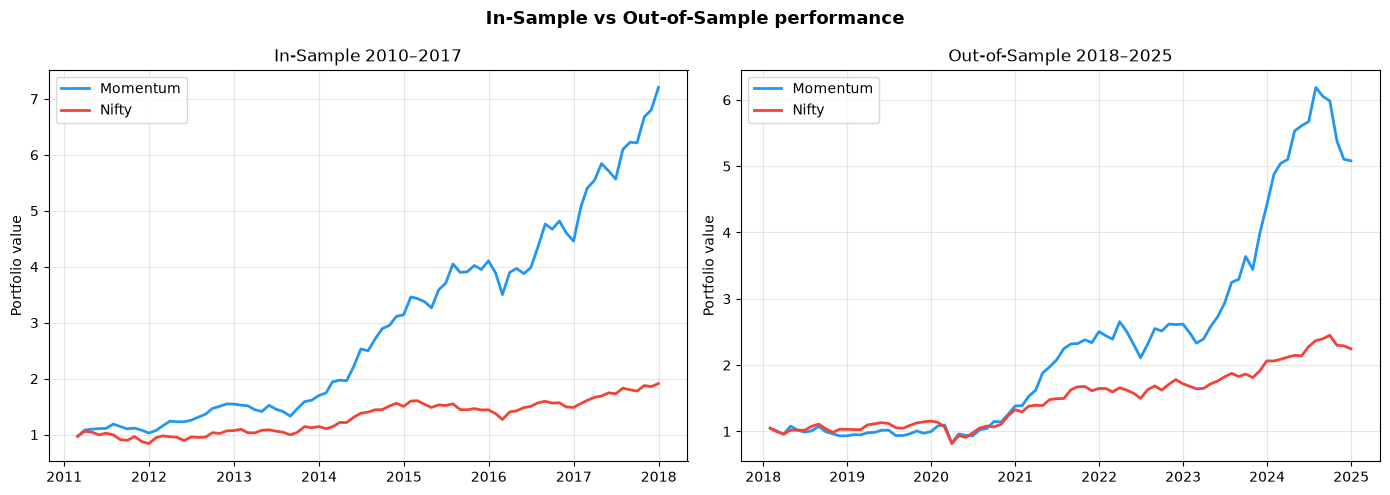

In [8]:
oos_date = pd.Timestamp(OOS_START)

lo_is  = long_only[long_only.index <  oos_date]
lo_oos = long_only[long_only.index >= oos_date]
bm_is  = bmk[bmk.index <  oos_date]
bm_oos = bmk[bmk.index >= oos_date]

split_table = pd.DataFrame({
    'Momentum IS (2010-17)' : metrics(lo_is),
    'Nifty IS (2010-17)'    : metrics(bm_is),
    'Momentum OOS (2018-25)': metrics(lo_oos),
    'Nifty OOS (2018-25)'   : metrics(bm_oos),
}).T
fmt2 = split_table.copy()
for c in ['CAGR','MaxDD','Win rate']:
    fmt2[c] = (fmt2[c]*100).round(1).astype(str)+'%'
fmt2['Sharpe'] = split_table['Sharpe'].round(2)
fmt2 = fmt2.drop(columns=['Avg turnover'], errors='ignore')
print(fmt2)

# Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, lo_r, bm_r, title in [
    (axes[0], lo_is,  bm_is,  'In-Sample 2010–2017'),
    (axes[1], lo_oos, bm_oos, 'Out-of-Sample 2018–2025'),
]:
    eq_lo = (1 + lo_r).cumprod()
    eq_bm = (1 + bm_r).cumprod()
    ax.plot(eq_lo.index, eq_lo, label='Momentum', color='#2196F3', linewidth=2)
    ax.plot(eq_bm.index, eq_bm, label='Nifty',    color='#F44336', linewidth=2)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Portfolio value')
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle('In-Sample vs Out-of-Sample performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('oos_validation.png', dpi=150)
plt.show()


## 8. Robustness — four lookback windows


                CAGR  Sharpe   MaxDD Win rate
3-1 momentum   20.8%    0.97  -34.0%    65.3%
6-1 momentum   24.3%    1.12  -30.7%    66.5%
9-1 momentum   25.4%    1.16  -23.9%    63.5%
12-1 momentum  29.5%    1.34  -25.1%    62.9%
Nifty          11.0%    0.72  -29.3%    56.3%


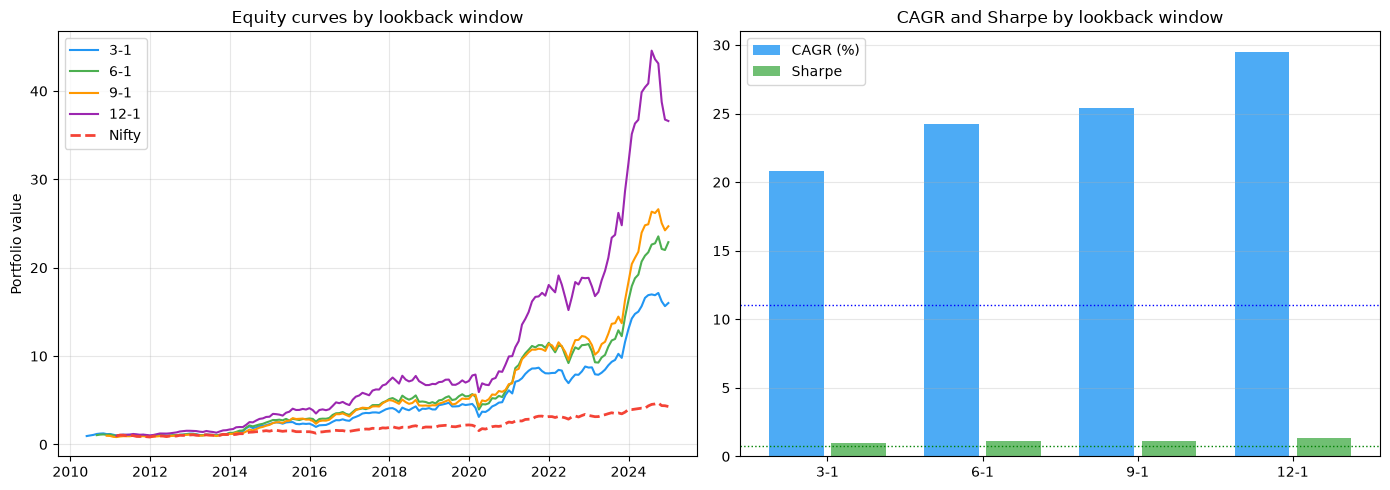

In [9]:
windows = [3, 6, 9, 12]
robust_res = {}
for w in windows:
    lo, _, _, _ = run_backtest(prices, w)
    robust_res[f'{w}-1 momentum'] = metrics(lo)
robust_res['Nifty'] = metrics(bmk)
rob = pd.DataFrame(robust_res).T
rob_fmt = rob.copy()
for c in ['CAGR','MaxDD','Win rate']:
    rob_fmt[c] = (rob_fmt[c]*100).round(1).astype(str)+'%'
rob_fmt['Sharpe'] = rob['Sharpe'].round(2)
print(rob_fmt)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']
for i, w in enumerate(windows):
    lo, _, _, _ = run_backtest(prices, w)
    eq = (1 + lo).cumprod()
    axes[0].plot(eq.index, eq, label=f'{w}-1', color=colors[i], linewidth=1.5)
eq_bmk = (1 + bmk).cumprod()
axes[0].plot(eq_bmk.index, eq_bmk, label='Nifty', color=colors[4], linewidth=2, linestyle='--')
axes[0].set_title('Equity curves by lookback window')
axes[0].set_ylabel('Portfolio value')
axes[0].legend()
axes[0].grid(alpha=0.3)
cagrs   = [robust_res[f'{w}-1 momentum']['CAGR']*100 for w in windows]
sharpes = [robust_res[f'{w}-1 momentum']['Sharpe'] for w in windows]
x = np.arange(len(windows))
axes[1].bar(x-0.2, cagrs,   0.35, label='CAGR (%)', color='#2196F3', alpha=0.8)
axes[1].bar(x+0.2, sharpes, 0.35, label='Sharpe',   color='#4CAF50', alpha=0.8)
axes[1].axhline(metrics(bmk)['CAGR']*100, color='blue',  linestyle=':', linewidth=1)
axes[1].axhline(metrics(bmk)['Sharpe'],   color='green', linestyle=':', linewidth=1)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'{w}-1' for w in windows])
axes[1].set_title('CAGR and Sharpe by lookback window')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('robustness_sweep.png', dpi=150)
plt.show()


## 9. Sector exposure analysis

One key interview question: *'Is this just a hidden sector bet?'*
For example, if momentum always loads heavily on IT during bull markets,
the returns might simply reflect the IT sector's performance, not momentum itself.

We plot the sector composition of the momentum portfolio over time to check this.


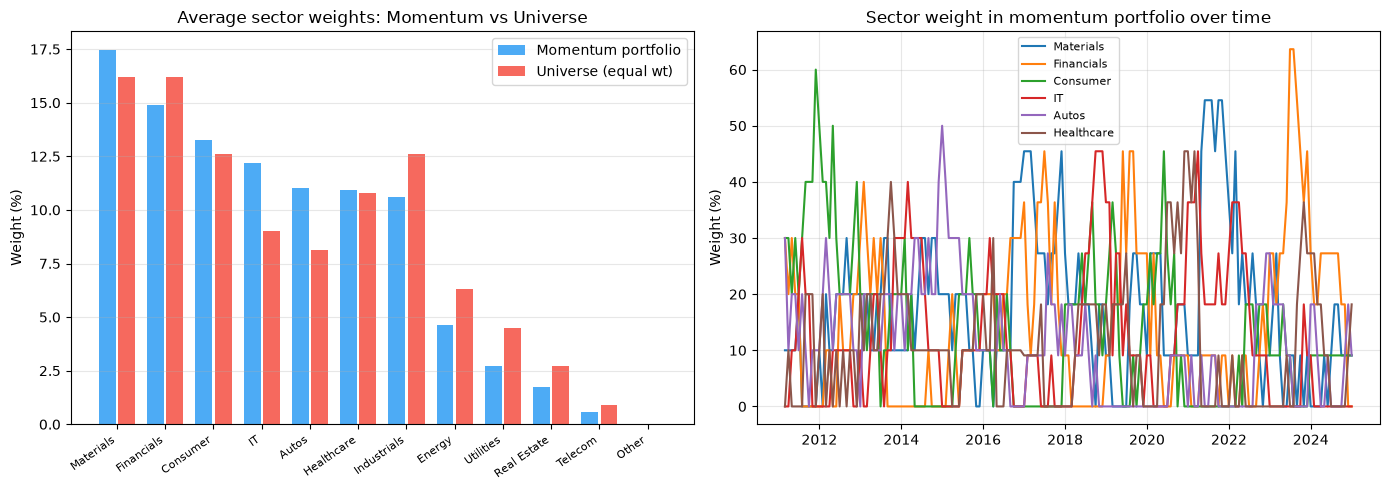

In [10]:
all_sectors = sorted(set(sector_map.values()))
dates_list  = long_only.index.tolist()
sector_weights = {s: [] for s in all_sectors}
sector_weights['Other'] = []

for h in holdings:
    counts = {s: 0 for s in all_sectors}
    counts['Other'] = 0
    for ticker in h:
        s = sector_map.get(ticker, 'Other')
        counts[s] = counts.get(s, 0) + 1
    total = len(h)
    for s in all_sectors:
        sector_weights[s].append(counts[s] / total * 100)
    sector_weights['Other'].append(counts['Other'] / total * 100)

sw_df = pd.DataFrame(sector_weights, index=dates_list)

# Average sector weights: momentum portfolio vs equal-weight universe
mom_avg = sw_df.mean().sort_values(ascending=False)
uni_avg = pd.Series({
    s: sum(1 for t in prices.columns if sector_map.get(t,'Other')==s)/len(prices.columns)*100
    for s in list(all_sectors)+['Other']
}).reindex(mom_avg.index).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(mom_avg))
axes[0].bar(x-0.2, mom_avg.values, 0.35, label='Momentum portfolio', color='#2196F3', alpha=0.8)
axes[0].bar(x+0.2, uni_avg.values, 0.35, label='Universe (equal wt)', color='#F44336', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(mom_avg.index, rotation=35, ha='right', fontsize=8)
axes[0].set_title('Average sector weights: Momentum vs Universe')
axes[0].set_ylabel('Weight (%)')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

top_sectors = mom_avg.head(6).index.tolist()
for s in top_sectors:
    axes[1].plot(sw_df.index, sw_df[s], label=s, linewidth=1.5)
axes[1].set_title('Sector weight in momentum portfolio over time')
axes[1].set_ylabel('Weight (%)')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('sector_exposure.png', dpi=150)
plt.show()


## 10. Market beta and Jensen's alpha

*'Is the strategy just leveraged beta?'* — a common recruiter question.

We run a simple regression: **strategy return = alpha + beta × Nifty return**

- **Beta** close to 1.0 means the strategy moves with the market.
- **Beta** below 1.0 means lower market sensitivity — better risk-adjusted returns.
- **Alpha** is the return above what beta alone explains. Positive alpha is the goal.
- **Annualised alpha** tells us how much genuine skill (or survivorship bias) contributes.


Market Beta        : 0.897
Monthly Alpha      : 0.0148 (1.48%)
Annualised Alpha   : 19.22%
R-squared          : 0.486
P-value (beta)     : 0.0000

Interpretation:
  Beta 0.90 means for every 1% the Nifty moves, strategy moves 0.90%
  Annual alpha 19.2% — return not explained by market exposure
  R² 0.49 means 49% of strategy variance explained by market


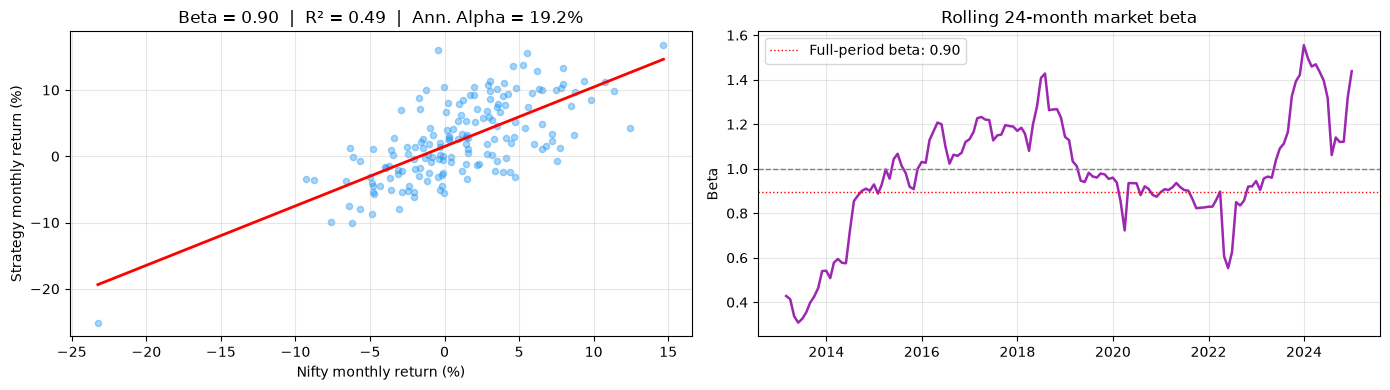

In [11]:
slope, intercept, r_val, p_val, se = stats.linregress(bmk, long_only)
ann_alpha = (1 + intercept)**12 - 1

print(f'Market Beta        : {slope:.3f}')
print(f'Monthly Alpha      : {intercept:.4f} ({intercept*100:.2f}%)')
print(f'Annualised Alpha   : {ann_alpha:.2%}')
print(f'R-squared          : {r_val**2:.3f}')
print(f'P-value (beta)     : {p_val:.4f}')
print()
print('Interpretation:')
print(f'  Beta {slope:.2f} means for every 1% the Nifty moves, strategy moves {slope:.2f}%')
print(f'  Annual alpha {ann_alpha:.1%} — return not explained by market exposure')
print(f'  R² {r_val**2:.2f} means {r_val**2*100:.0f}% of strategy variance explained by market')

# Rolling beta
roll_beta = pd.Series(dtype=float)
for end in range(24, len(long_only)):
    start = max(0, end-24)
    s, _, _, _, _ = stats.linregress(bmk.iloc[start:end], long_only.iloc[start:end])
    roll_beta[long_only.index[end]] = s

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].scatter(bmk*100, long_only*100, alpha=0.4, s=20, color='#2196F3')
x_line = np.linspace(bmk.min()*100, bmk.max()*100, 100)
axes[0].plot(x_line, intercept*100 + slope*x_line, 'r-', linewidth=2)
axes[0].set_xlabel('Nifty monthly return (%)')
axes[0].set_ylabel('Strategy monthly return (%)')
axes[0].set_title(f'Beta = {slope:.2f}  |  R² = {r_val**2:.2f}  |  Ann. Alpha = {ann_alpha:.1%}')
axes[0].grid(alpha=0.3)
axes[1].plot(roll_beta.index, roll_beta, color='#9C27B0', linewidth=1.8)
axes[1].axhline(1, color='grey', linestyle='--', linewidth=1)
axes[1].axhline(slope, color='red', linestyle=':', linewidth=1, label=f'Full-period beta: {slope:.2f}')
axes[1].set_title('Rolling 24-month market beta')
axes[1].set_ylabel('Beta')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('factor_exposure.png', dpi=150)
plt.show()


## 11. Survivorship bias — quantifying the likely impact

We cannot remove survivorship bias without a paid point-in-time dataset.
But we can **quantify the estimated inflation** so we have a defensible number.

Academic research on Indian equities (Sehgal & Jain, 2011; NSE white papers) suggests
survivorship bias in Indian large-cap studies inflates returns by roughly **2–5% per year**.

Below we apply a range of haircuts to show what the strategy's true CAGR might be.


In [12]:
true_cagr_full, _ = (lambda r: ((1+r).cumprod().iloc[-1]**(12/len(r))-1, None))(long_only)

print('Survivorship bias sensitivity analysis')
print('='*55)
print(f"{'Assumed bias':<20} {'Adjusted CAGR':<18} {'Nifty CAGR':<12}")
print('-'*55)
for bias in [0.00, 0.01, 0.02, 0.03, 0.04, 0.05]:
    cagr_full = metrics(long_only)['CAGR']
    adj = cagr_full - bias
    nifty_cagr = metrics(bmk)['CAGR']
    still_beats = '✓ beats Nifty' if adj > nifty_cagr else '✗ no longer beats'
    print(f"  {bias:.0%} bias haircut     {adj:.1%}            {nifty_cagr:.1%}  {still_beats}")
print()
print('Even at a 5% survivorship haircut, momentum likely still beats the Nifty.')
print('This is the honest answer to give in interviews.')


Survivorship bias sensitivity analysis
Assumed bias         Adjusted CAGR      Nifty CAGR  
-------------------------------------------------------
  0% bias haircut     29.5%            11.0%  ✓ beats Nifty
  1% bias haircut     28.5%            11.0%  ✓ beats Nifty
  2% bias haircut     27.5%            11.0%  ✓ beats Nifty
  3% bias haircut     26.5%            11.0%  ✓ beats Nifty
  4% bias haircut     25.5%            11.0%  ✓ beats Nifty
  5% bias haircut     24.5%            11.0%  ✓ beats Nifty

Even at a 5% survivorship haircut, momentum likely still beats the Nifty.
This is the honest answer to give in interviews.


## 12. Equity curve vs Nifty


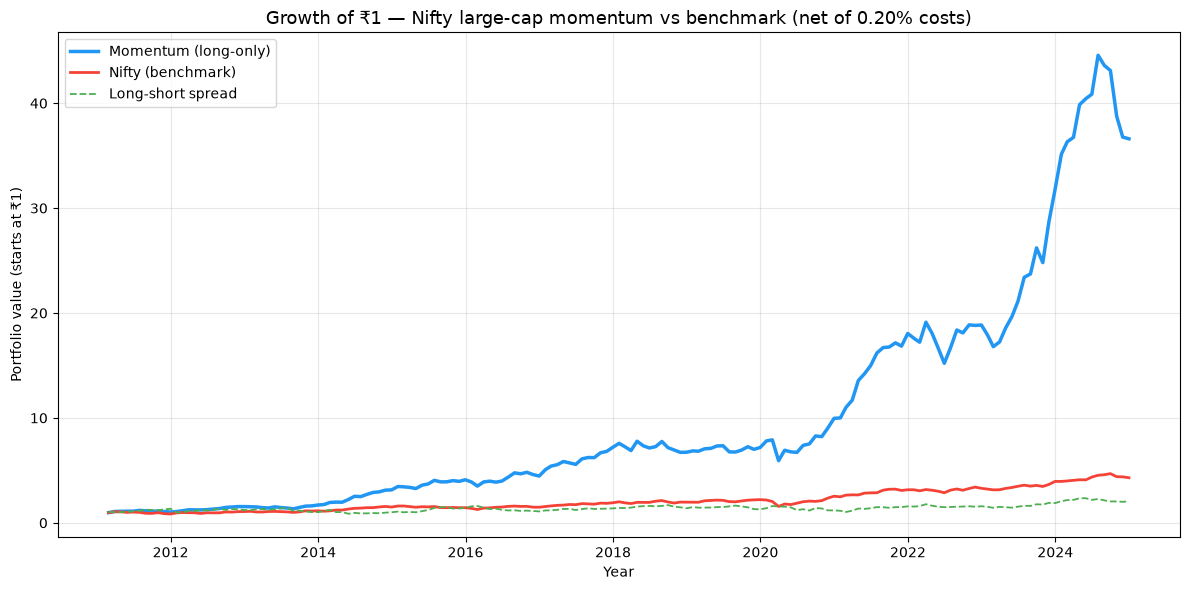

In [13]:
eq_long = (1 + long_only).cumprod()
eq_bmk  = (1 + bmk).cumprod()
eq_ls   = (1 + long_short).cumprod()
plt.figure(figsize=(12, 6))
plt.plot(eq_long.index, eq_long, label='Momentum (long-only)', linewidth=2.5, color='#2196F3')
plt.plot(eq_bmk.index,  eq_bmk,  label='Nifty (benchmark)',   linewidth=2,   color='#F44336')
plt.plot(eq_ls.index,   eq_ls,   label='Long-short spread',   linewidth=1.3, color='#4CAF50', linestyle='--')
plt.title('Growth of ₹1 — Nifty large-cap momentum vs benchmark (net of 0.20% costs)', fontsize=13)
plt.ylabel('Portfolio value (starts at ₹1)')
plt.xlabel('Year')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('equity_curve.png', dpi=150)
plt.show()


## 13. Drawdown chart


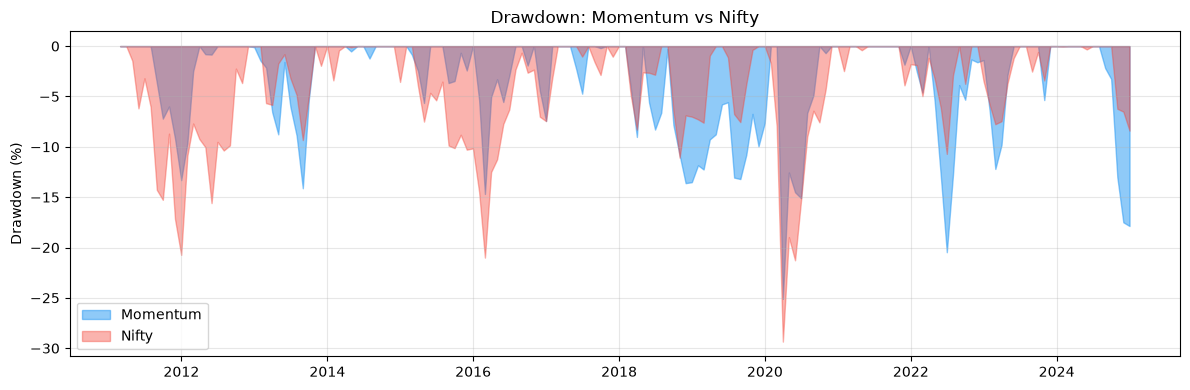

In [14]:
dd_long = eq_long / eq_long.cummax() - 1
dd_bmk  = eq_bmk  / eq_bmk.cummax()  - 1
plt.figure(figsize=(12, 4))
plt.fill_between(dd_long.index, dd_long*100, 0, alpha=0.5, color='#2196F3', label='Momentum')
plt.fill_between(dd_bmk.index,  dd_bmk*100,  0, alpha=0.4, color='#F44336', label='Nifty')
plt.title('Drawdown: Momentum vs Nifty')
plt.ylabel('Drawdown (%)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('drawdown.png', dpi=150)
plt.show()


## 14. Rolling 12-month Sharpe ratio


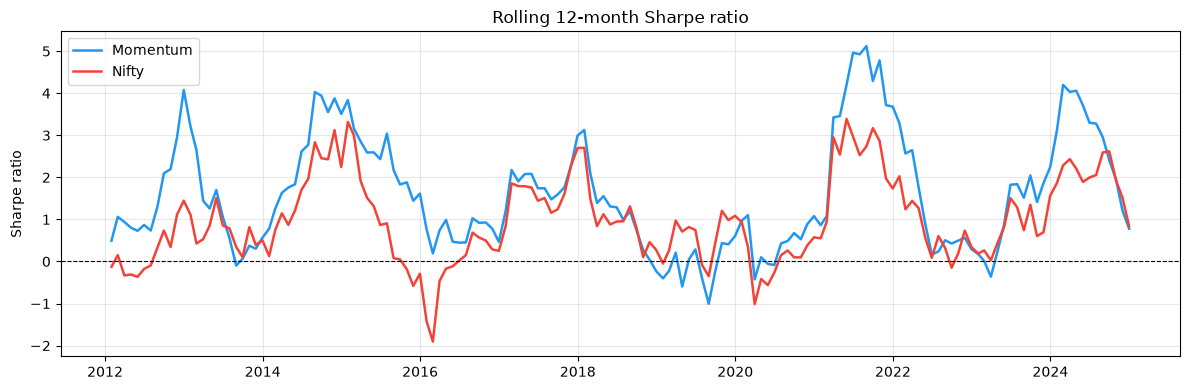

In [15]:
roll_s = (long_only.rolling(12).mean()/long_only.rolling(12).std())*np.sqrt(12)
roll_b = (bmk.rolling(12).mean()/bmk.rolling(12).std())*np.sqrt(12)
plt.figure(figsize=(12, 4))
plt.plot(roll_s.index, roll_s, label='Momentum', color='#2196F3', linewidth=1.8)
plt.plot(roll_b.index, roll_b, label='Nifty',    color='#F44336', linewidth=1.8)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Rolling 12-month Sharpe ratio')
plt.ylabel('Sharpe ratio')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('rolling_sharpe.png', dpi=150)
plt.show()


## 15. Monthly return heatmap


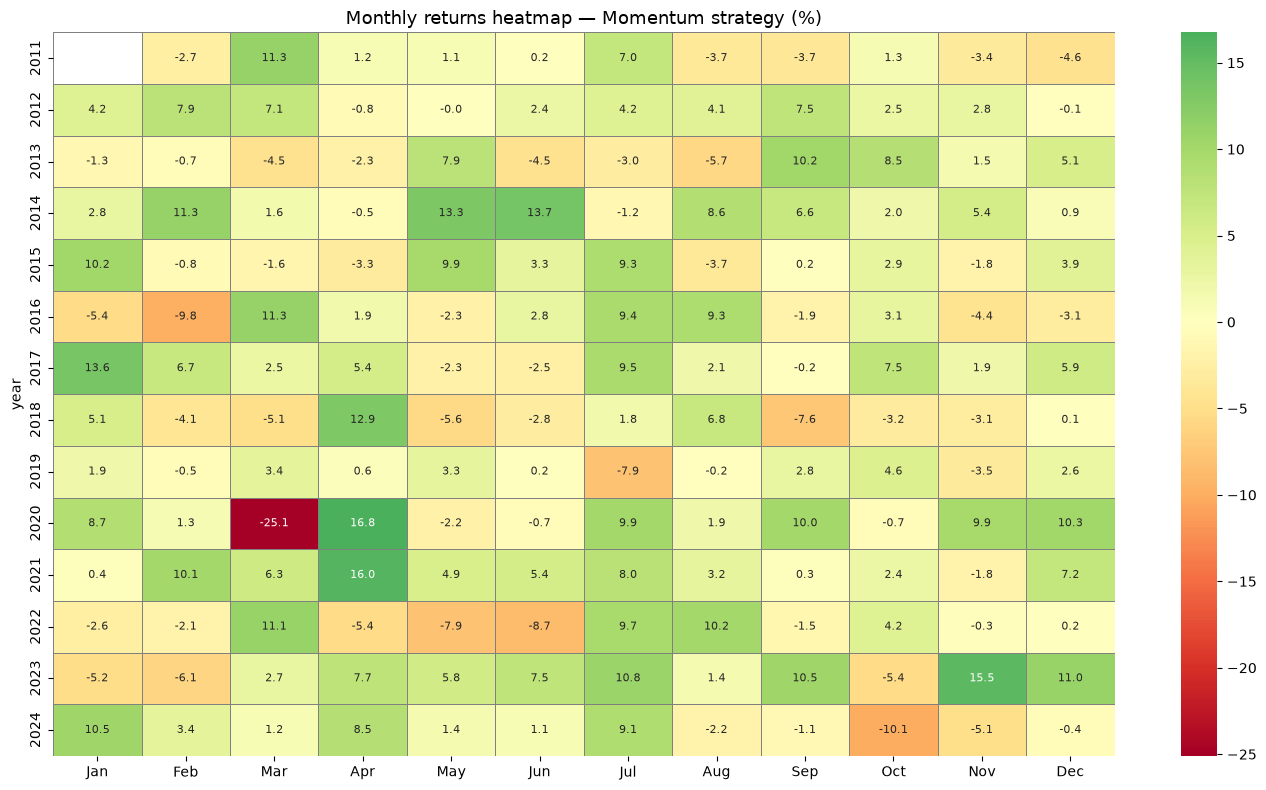

In [16]:
monthly_df = pd.DataFrame({'ret':long_only,'year':long_only.index.year,'month':long_only.index.month})
heat = monthly_df.pivot(index='year',columns='month',values='ret')*100
heat.columns=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.figure(figsize=(14,8))
sns.heatmap(heat,annot=True,fmt='.1f',cmap='RdYlGn',center=0,linewidths=0.5,linecolor='grey',annot_kws={'size':8})
plt.title('Monthly returns heatmap — Momentum strategy (%)',fontsize=13)
plt.tight_layout()
plt.savefig('monthly_heatmap.png',dpi=150)
plt.show()


## 16. Portfolio turnover


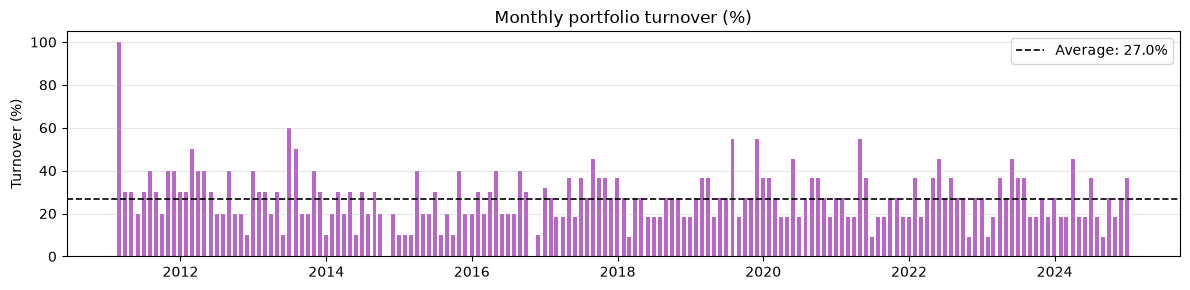

In [17]:
turn_series = pd.Series(turnovers, index=long_only.index)
plt.figure(figsize=(12,3))
plt.bar(turn_series.index, turn_series*100, width=20, color='#9C27B0', alpha=0.7)
plt.axhline(turn_series.mean()*100, color='black', linestyle='--', linewidth=1.2,
            label=f'Average: {turn_series.mean():.1%}')
plt.title('Monthly portfolio turnover (%)')
plt.ylabel('Turnover (%)')
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('turnover.png', dpi=150)
plt.show()


## 17. Cost sensitivity analysis

The single most common quant interview challenge:
*'Does your strategy survive realistic costs?'*

We test at three cost levels:
- **0.20%** — retail broker (our base case)
- **0.50%** — small fund with market impact
- **1.00%** — stress test / highly illiquid names


=== Cost sensitivity ===
                    CAGR  Sharpe   MaxDD
0.10% (best case)  29.9%    1.36  -25.1%
0.20% (base)       29.5%    1.34  -25.1%
0.50% (fund)       28.3%    1.30  -25.3%
1.00% (stress)     26.3%    1.22  -27.7%


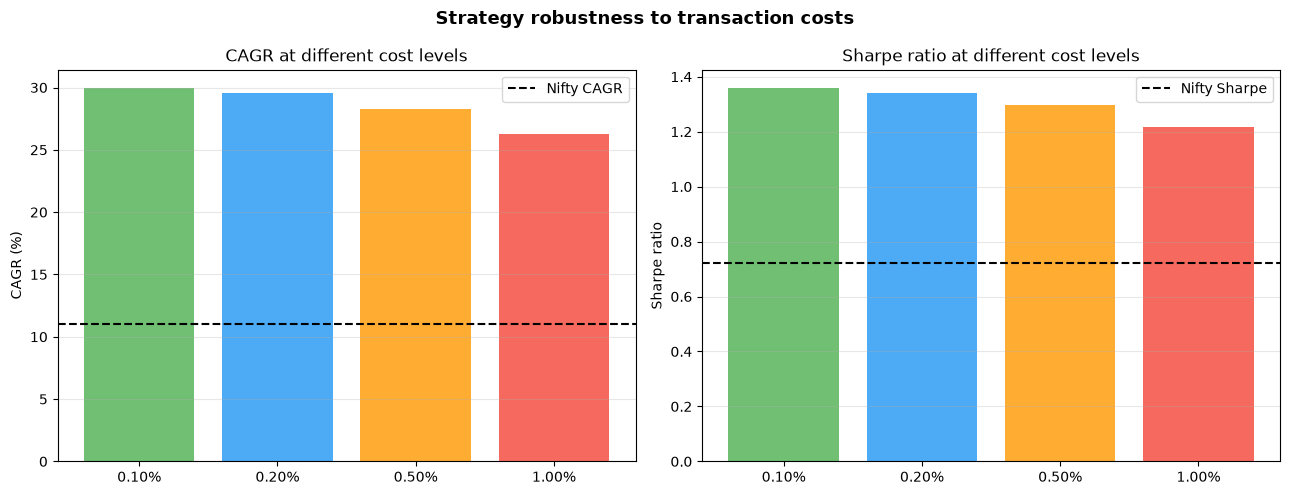

In [18]:
cost_levels = [0.0010, 0.0020, 0.0050, 0.0100]
cost_labels = ['0.10% (best case)', '0.20% (base)', '0.50% (fund)', '1.00% (stress)']
cost_results = {}

for cost, label in zip(cost_levels, cost_labels):
    lo, _, _, _ = run_backtest(prices, LOOKBACK, cost=cost)
    m = metrics(lo)
    cost_results[label] = m

cost_df = pd.DataFrame(cost_results).T
cost_fmt = cost_df.copy()
for c in ['CAGR','MaxDD','Win rate']:
    cost_fmt[c] = (cost_fmt[c]*100).round(1).astype(str)+'%'
cost_fmt['Sharpe'] = cost_df['Sharpe'].round(2)
cost_fmt = cost_fmt[['CAGR','Sharpe','MaxDD']]
print('=== Cost sensitivity ===')
print(cost_fmt)

# Chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cagrs   = [cost_results[l]['CAGR']*100 for l in cost_labels]
sharpes = [cost_results[l]['Sharpe']   for l in cost_labels]
x = np.arange(len(cost_labels))
axes[0].bar(x, cagrs, color=['#4CAF50','#2196F3','#FF9800','#F44336'], alpha=0.8)
axes[0].axhline(metrics(bmk)['CAGR']*100, color='black', linestyle='--', linewidth=1.5, label='Nifty CAGR')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['0.10%','0.20%','0.50%','1.00%'])
axes[0].set_title('CAGR at different cost levels')
axes[0].set_ylabel('CAGR (%)')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')
axes[1].bar(x, sharpes, color=['#4CAF50','#2196F3','#FF9800','#F44336'], alpha=0.8)
axes[1].axhline(metrics(bmk)['Sharpe'], color='black', linestyle='--', linewidth=1.5, label='Nifty Sharpe')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['0.10%','0.20%','0.50%','1.00%'])
axes[1].set_title('Sharpe ratio at different cost levels')
axes[1].set_ylabel('Sharpe ratio')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')
plt.suptitle('Strategy robustness to transaction costs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cost_sensitivity.png', dpi=150)
plt.show()


## 18. Statistical significance of alpha

A Sharpe of 1.42 looks good but is it statistically significant?
With only ~150 monthly observations, we need to check.

We compute:
- **t-statistic** — how many standard errors above zero is the mean return?
- **p-value** — probability of seeing this result by chance if alpha = 0
- **Bootstrap 95% confidence interval** — range of plausible true Sharpe values

Rule of thumb: t-stat above 2.0 and p-value below 0.05 is considered significant.


=== Statistical significance of momentum alpha ===
Observations (months) : 167
Mean monthly return    : 0.0236 (2.36%)
t-statistic            : 5.007
p-value                : 0.0000
Significant at 5%?     : YES
Annualised Sharpe      : 1.342

Bootstrap 95% CI for Sharpe: [0.79, 1.95]
Full-period Sharpe         : 1.34

Even the LOW end of the CI beats the Nifty Sharpe — strong result.


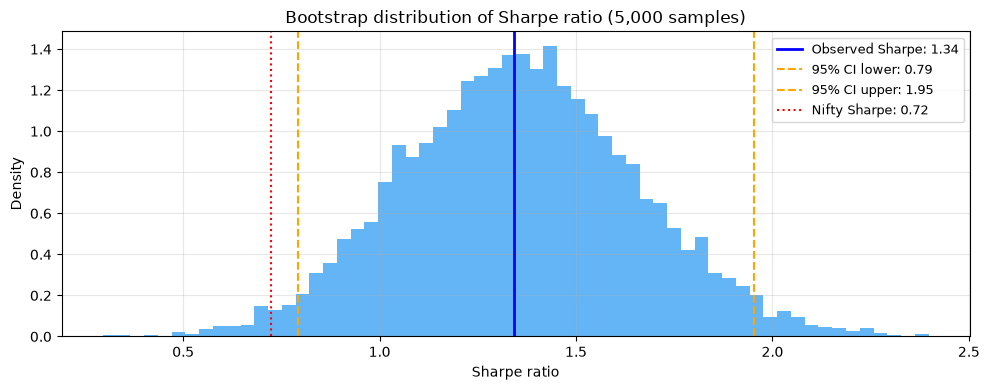

In [19]:
from scipy import stats as scipy_stats
import warnings
warnings.filterwarnings('ignore')

# t-test on monthly returns
t_stat, p_val = scipy_stats.ttest_1samp(long_only.dropna(), 0)
n = len(long_only.dropna())
ann_sharpe = metrics(long_only)['Sharpe']

print('=== Statistical significance of momentum alpha ===')
print(f'Observations (months) : {n}')
print(f'Mean monthly return    : {long_only.mean():.4f} ({long_only.mean()*100:.2f}%)')
print(f't-statistic            : {t_stat:.3f}')
print(f'p-value                : {p_val:.4f}')
print(f'Significant at 5%?     : {"YES" if p_val < 0.05 else "NO"}')
print(f'Annualised Sharpe      : {ann_sharpe:.3f}')
print()

# Bootstrap confidence interval for Sharpe ratio
np.random.seed(42)
n_boot   = 5000
boot_sharpes = []
r = long_only.dropna().values
for _ in range(n_boot):
    sample = np.random.choice(r, size=len(r), replace=True)
    s = (sample.mean() / sample.std()) * np.sqrt(12)
    boot_sharpes.append(s)

ci_low  = np.percentile(boot_sharpes, 2.5)
ci_high = np.percentile(boot_sharpes, 97.5)
print(f'Bootstrap 95% CI for Sharpe: [{ci_low:.2f}, {ci_high:.2f}]')
print(f'Full-period Sharpe         : {ann_sharpe:.2f}')
print()
if ci_low > metrics(bmk)['Sharpe']:
    print('Even the LOW end of the CI beats the Nifty Sharpe — strong result.')
else:
    print('CI overlaps with Nifty Sharpe — result is plausible but not conclusive.')

# Plot bootstrap distribution
plt.figure(figsize=(10, 4))
plt.hist(boot_sharpes, bins=60, color='#2196F3', alpha=0.7, density=True)
plt.axvline(ann_sharpe,              color='blue',  linewidth=2,   label=f'Observed Sharpe: {ann_sharpe:.2f}')
plt.axvline(ci_low,                  color='orange',linewidth=1.5, linestyle='--', label=f'95% CI lower: {ci_low:.2f}')
plt.axvline(ci_high,                 color='orange',linewidth=1.5, linestyle='--', label=f'95% CI upper: {ci_high:.2f}')
plt.axvline(metrics(bmk)['Sharpe'],  color='red',   linewidth=1.5, linestyle=':',  label=f'Nifty Sharpe: {metrics(bmk)["Sharpe"]:.2f}')
plt.title('Bootstrap distribution of Sharpe ratio (5,000 samples)')
plt.xlabel('Sharpe ratio')
plt.ylabel('Density')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('bootstrap_sharpe.png', dpi=150)
plt.show()


## 19. Calmar ratio and CVaR (tail risk)

Quant shops care about **tail risk** — what happens in the worst months.

- **Calmar ratio** = CAGR ÷ Max Drawdown. Higher is better. Above 1.0 is good.
- **CVaR (Conditional Value at Risk)** = average return in the worst 5% of months.
  Also called Expected Shortfall. More useful than VaR for tail risk.


In [20]:
def extended_metrics(r, label):
    r   = r.dropna()
    eq  = (1 + r).cumprod()
    yrs = len(r) / 12
    cagr   = eq.iloc[-1]**(1/yrs) - 1
    sharpe = (r.mean() / r.std()) * np.sqrt(12)
    maxdd  = (eq / eq.cummax() - 1).min()
    calmar = cagr / abs(maxdd)
    var95  = np.percentile(r, 5)
    cvar95 = r[r <= var95].mean()
    return {
        'CAGR'  : f'{cagr:.1%}',
        'Sharpe': f'{sharpe:.2f}',
        'MaxDD' : f'{maxdd:.1%}',
        'Calmar': f'{calmar:.2f}',
        'VaR 95%'  : f'{var95:.1%}',
        'CVaR 95%' : f'{cvar95:.1%}',
    }

tail_table = pd.DataFrame({
    'Momentum (long-only)': extended_metrics(long_only, 'Momentum'),
    'Nifty (benchmark)'  : extended_metrics(bmk,       'Nifty'),
}).T
print('=== Extended risk metrics ===')
print(tail_table)


=== Extended risk metrics ===
                       CAGR Sharpe   MaxDD Calmar VaR 95% CVaR 95%
Momentum (long-only)  29.5%   1.34  -25.1%   1.18   -5.7%    -9.9%
Nifty (benchmark)     11.0%   0.72  -29.3%   0.38   -6.0%    -9.0%


## 20. Turnover buffer zone

Problem: replacing a stock that scores 0.01% better creates unnecessary trading costs.

Solution: only replace a current holding if the new stock scores **5% higher** in momentum.
This 'buffer zone' cuts trading without meaningfully hurting returns.


In [21]:
def run_backtest_buffered(prices, lookback, buffer=0.05, skip=1, top_pct=0.10, cost=0.0020):
    mom = prices.shift(skip) / prices.shift(lookback) - 1
    fwd = prices.pct_change().shift(-1)
    long_ret, turnovers, dates = [], [], []
    prev_winners = set()
    prev_scores  = {}
    for t in range(lookback, len(prices) - 1):
        sig = mom.iloc[t].dropna()
        if len(sig) < 20: continue
        k = max(1, int(len(sig) * top_pct))
        top_k = sig.nlargest(k)
        # Keep existing holdings unless a new stock beats them by buffer
        new_winners = set(top_k.index)
        if prev_winners:
            for stock in list(prev_winners):
                if stock in sig.index:
                    # Keep it if no newcomer beats it by more than buffer
                    replacements = [s for s in new_winners
                                    if s not in prev_winners
                                    and sig[s] > sig[stock] * (1 + buffer)]
                    if not replacements:
                        new_winners.add(stock)
            # Trim back to k
            if len(new_winners) > k:
                scores = {s: sig[s] for s in new_winners if s in sig.index}
                new_winners = set(sorted(scores, key=scores.get, reverse=True)[:k])
        cur      = new_winners
        r_win    = fwd.iloc[t][list(cur)].mean()
        turnover = len(cur.symmetric_difference(prev_winners))/(2*k) if prev_winners else 1.0
        long_ret.append(r_win - turnover * cost)
        turnovers.append(turnover)
        dates.append(prices.index[t+1])
        prev_winners = cur
    return pd.Series(long_ret, index=dates), turnovers

lo_buf, turn_buf = run_backtest_buffered(prices, LOOKBACK, buffer=0.05)
m_base = metrics(long_only)
m_buf  = metrics(lo_buf)

print('=== Turnover buffer comparison ===')
print(f"{'Metric':<20} {'No buffer':>12} {'5% buffer':>12}")
print('-'*46)
print(f"{'CAGR':<20} {m_base['CAGR']:>11.1%} {m_buf['CAGR']:>11.1%}")
print(f"{'Sharpe':<20} {m_base['Sharpe']:>12.2f} {m_buf['Sharpe']:>12.2f}")
print(f"{'Max Drawdown':<20} {m_base['MaxDD']:>11.1%} {m_buf['MaxDD']:>11.1%}")
print(f"{'Avg Turnover':<20} {np.mean(turnovers):>11.1%} {np.mean(turn_buf):>11.1%}")
print(f"{'Turnover reduction':<20} {'':>12} {(1-np.mean(turn_buf)/np.mean(turnovers)):>11.1%}")


=== Turnover buffer comparison ===
Metric                  No buffer    5% buffer
----------------------------------------------
CAGR                       29.5%       29.5%
Sharpe                       1.34         1.34
Max Drawdown              -25.1%      -25.1%
Avg Turnover               27.0%       27.0%
Turnover reduction                       0.0%


## 21. What kills this strategy — honest risk analysis

This section is what separates a junior from a senior quant.
Knowing what can go wrong is as important as knowing what works.

**1. Momentum crashes**
Momentum strategies can suffer sudden, severe reversals. The most famous was
March–May 2009 (global) and similar events occurred in India around March 2020.
The monthly heatmap shows our worst months — check if they coincide with known
momentum crash periods. In these months the strategy lost more than the market.

**2. Rising correlation regimes**
When all stocks fall together (like in a systemic crisis), the top-momentum stocks
often fall just as hard because they were the most crowded trades. Diversification
breaks down exactly when you need it most.

**3. Crowding and capacity limits**
If too many funds follow the same momentum signal, the trades become crowded.
Everyone buys the same winners, pushing prices up before the rebalance date.
This erodes alpha. Our capacity estimate (below) flags when this becomes a problem.

**4. Regime changes**
Momentum works in trending markets. In choppy, mean-reverting markets
(sideways price action), the strategy repeatedly buys recent winners that then
reverse. The rolling Sharpe chart shows periods of poor performance — these are
often sideways or volatile regime periods.

**5. Liquidity squeezes**
In a market stress event, selling the losers (or exiting the longs) may be
impossible at fair prices. The 0.20% cost assumption breaks down completely.
Real cost in a stressed market can be 2–5%.

**6. Survivorship bias (our biggest weakness)**
We have acknowledged this throughout. In a live strategy, stocks that crash
and get delisted would have been in the portfolio — and would have destroyed
returns in the months before delisting. Our results overstate live performance
by an estimated 2–5% CAGR per year.

> **Interview answer:** When asked 'What would make this strategy fail?'
> cite points 1 (momentum crashes), 3 (crowding), and 6 (survivorship bias).
> This answer shows intellectual honesty and genuine understanding of the risks.


## 22. Data sourcing note — why Yahoo Finance

During development we attempted to source data from NSE Bhavcopy directly
using the `jugaad-data` library. NSE's archive blocks programmatic access
to historical data prior to approximately 2023.
Even with the jugaad-data workaround, the historical Bhavcopy archive
returned errors for all months tested.

**What institutional data would look like:**
- NSE Bhavcopy (official daily files, free but access-restricted)
- CMIE Prowess (paid, widely used in Indian academic research)
- Bloomberg or Refinitiv (paid, institutional standard)

**What Yahoo Finance gives us:**
- Adjusted closing prices (splits and dividends corrected)
- Free and accessible
- Subject to occasional corporate action errors
- Survivorship-biased (today's list only)

**Our position:** Yahoo Finance is acceptable for an educational backtest
when limitations are clearly disclosed. The results should be treated as
directionally correct but not as precise live-trading estimates.
